# Preprocessing Data – HR Analytics
## Perbandingan Fuzzy Mamdani dan Fuzzy Sugeno dalam Penilaian Performa Karyawan

Notebook ini mencakup seluruh tahapan preprocessing data sebelum implementasi sistem fuzzy, meliputi:
1. Load & seleksi variabel
2. Penanganan missing values
3. Statistik deskriptif
4. Pemeriksaan outlier
5. Visualisasi distribusi data
6. Analisis korelasi
7. Penentuan batas membership function

---
## 1. Import Library & Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CSV_FILE = "Employee_Performance_Dataset.csv"
data = pd.read_csv(CSV_FILE)

print(f"Shape dataset asli : {data.shape}")
print(f"Kolom               : {list(data.columns)}")
data.head()

Shape dataset asli : (5000, 13)
Kolom               : ['Employee ID', 'Name', 'Department', 'Job Role', 'Performance Score', 'KPI Score', 'Attendance (%)', 'Peer Rating', 'Task Completion (%)', 'Work Hours Logged', 'Manager Feedback', 'Training Hours', 'Promotion Eligibility']


,Employee ID,Name,Department,Job Role,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Manager Feedback,Training Hours,Promotion Eligibility
0,376063,Manikya Badami,Sales,Sales Executive,61,91.03,94.40,4.5,78.19,42,3.7,18,No
1,810690,Zara Mahal,Marketing,Marketing Executive,91,83.36,78.45,4.7,71.39,46,4.5,15,Yes
2,520956,Sana Gera,Finance,Accountant,100,65.39,99.50,4.4,80.20,51,3.5,7,No
3,202996,Zoya Wadhwa,Marketing,Content Strategist,100,82.90,79.83,4.3,71.51,43,5.0,9,Yes
4,383410,Baiju Doctor,Sales,Sales Executive,80,90.90,89.92,3.7,78.03,51,3.1,29,No


---
## 2. Seleksi Variabel

Dari 13 kolom yang tersedia, dipilih **6 variabel input** dan **1 variabel output** yang relevan untuk sistem fuzzy penilaian performa karyawan:

| Peran | Variabel | Alasan Pemilihan |
|---|---|---|
| Input | KPI Score | Mengukur produktivitas dan pencapaian target |
| Input | Attendance (%) | Mencerminkan kedisiplinan dan kehadiran |
| Input | Peer Rating | Evaluasi rekan kerja terhadap kolaborasi |
| Input | Task Completion (%) | Tingkat penyelesaian tugas yang diberikan |
| Input | Manager Feedback | Evaluasi langsung dari atasan |
| Input | Training Hours | Intensitas pengembangan kemampuan |
| Output | Performance Score | Nilai performa aktual sebagai acuan evaluasi |

Kolom lain (`Employee ID`, `Name`, `Department`, `Job Role`, `Work Hours Logged`, `Promotion Eligibility`) tidak digunakan karena bersifat identitas atau di luar cakupan input fuzzy.

In [5]:
INPUT_COLS  = ['KPI Score', 'Attendance (%)', 'Peer Rating',
               'Task Completion (%)', 'Manager Feedback', 'Training Hours']
OUTPUT_COL  = 'Performance Score'
SELECTED    = INPUT_COLS + [OUTPUT_COL]

df = data[SELECTED].copy()
print(f"Shape setelah seleksi variabel : {df.shape}")
df.head()

Shape setelah seleksi variabel : (5000, 7)


,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Manager Feedback,Training Hours,Performance Score
0,91.03,94.40,4.5,78.19,3.7,18,61
1,83.36,78.45,4.7,71.39,4.5,15,91
2,65.39,99.50,4.4,80.20,3.5,7,100
3,82.90,79.83,4.3,71.51,5.0,9,100
4,90.90,89.92,3.7,78.03,3.1,29,80


---
## 3. Penanganan Missing Values

Pemeriksaan nilai kosong (null/NaN) dilakukan pada seluruh kolom terpilih. Jika ditemukan, baris tersebut akan dihapus (`dropna`) karena jumlahnya biasanya kecil dan tidak merusak representasi data.

In [6]:
print("=== Jumlah Missing Values per Kolom ===")
print(df.isnull().sum())
print(f"\nTotal missing values : {df.isnull().sum().sum()}")

rows_before = len(df)
df = df.dropna()
rows_after  = len(df)
print(f"\nBaris sebelum dropna : {rows_before}")
print(f"Baris setelah dropna : {rows_after}")
print(f"Baris dihapus        : {rows_before - rows_after}")

=== Jumlah Missing Values per Kolom ===
KPI Score              0
Attendance (%)         0
Peer Rating            0
Task Completion (%)    0
Manager Feedback       0
Training Hours         0
Performance Score      0
dtype: int64

Total missing values : 0

Baris sebelum dropna : 5000
Baris setelah dropna : 5000
Baris dihapus        : 0


---
## 4. Statistik Deskriptif

Statistik deskriptif (min, max, mean, median, standar deviasi, kuartil) dihitung untuk setiap variabel. Nilai-nilai ini menjadi **acuan utama dalam menentukan batas membership function** pada sistem fuzzy.

In [7]:
print(f"{'Variabel':<22} {'Min':>8} {'Q1':>8} {'Median':>8} {'Mean':>8} {'Q3':>8} {'Max':>8} {'Std':>8}")
print("-" * 80)
for col in SELECTED:
    mn  = df[col].min()
    q1  = df[col].quantile(0.25)
    med = df[col].median()
    avg = df[col].mean()
    q3  = df[col].quantile(0.75)
    mx  = df[col].max()
    std = df[col].std()
    print(f"{col:<22} {mn:>8.2f} {q1:>8.2f} {med:>8.2f} {avg:>8.2f} {q3:>8.2f} {mx:>8.2f} {std:>8.2f}")

Variabel                    Min       Q1   Median     Mean       Q3      Max      Std
--------------------------------------------------------------------------------
KPI Score                 60.01    68.33    77.34    77.38    86.05    94.99    10.16
Attendance (%)            75.01    81.13    87.41    87.47    93.75   100.00     7.23
Peer Rating                3.00     3.50     4.00     4.00     4.50     5.00     0.58
Task Completion (%)       70.01    77.32    85.12    84.98    92.47   100.00     8.70
Manager Feedback           3.00     3.50     4.00     4.00     4.50     5.00     0.58
Training Hours             0.00     7.00    15.00    14.88    23.00    30.00     9.01
Performance Score         50.00    62.00    75.00    74.78    87.00   100.00    14.67


---
## 5. Pemeriksaan Outlier (Metode IQR)

Outlier dideteksi menggunakan metode **IQR (Interquartile Range)**. Suatu nilai dikategorikan outlier apabila:

$$\text{nilai} < Q1 - 1.5 \times IQR \quad \text{atau} \quad \text{nilai} > Q3 + 1.5 \times IQR$$

Selain pengecekan numerik, boxplot divisualisasikan untuk melihat sebaran dan keberadaan outlier secara visual.

In [8]:
print("=== Deteksi Outlier (Metode IQR) ===")
print(f"{'Variabel':<22} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Batas Bawah':>12} {'Batas Atas':>12} {'Outlier':>8}")
print("-" * 85)
for col in SELECTED:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lb) | (df[col] > ub)).sum()
    print(f"{col:<22} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {lb:>12.2f} {ub:>12.2f} {n_out:>8}")

=== Deteksi Outlier (Metode IQR) ===
Variabel                     Q1       Q3      IQR  Batas Bawah   Batas Atas  Outlier
-------------------------------------------------------------------------------------
KPI Score                 68.33    86.05    17.72        41.74       112.63        0
Attendance (%)            81.13    93.75    12.62        62.20       112.69        0
Peer Rating                3.50     4.50     1.00         2.00         6.00        0
Task Completion (%)       77.32    92.47    15.16        54.58       115.20        0
Manager Feedback           3.50     4.50     1.00         2.00         6.00        0
Training Hours             7.00    23.00    16.00       -17.00        47.00        0
Performance Score         62.00    87.00    25.00        24.50       124.50        0


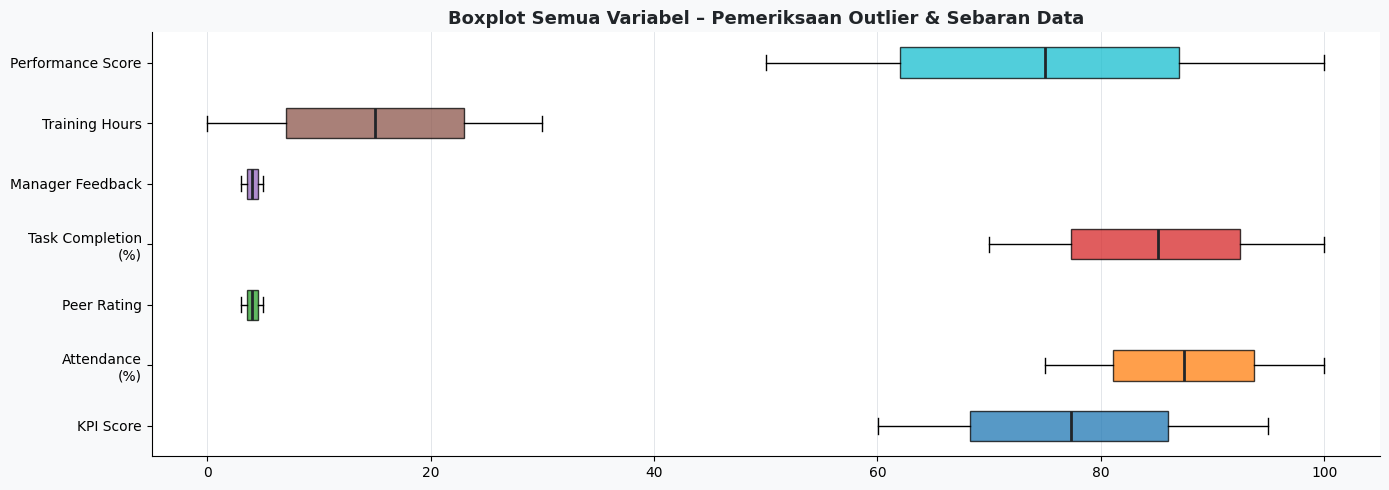

In [9]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#F8F9FA')
ax.set_facecolor('white')

COLORS = ['#1F77B4','#FF7F0E','#2CA02C','#D62728','#9467BD','#8C564B','#17BECF']
bplot  = ax.boxplot(
    [df[c] for c in SELECTED],
    vert=False, patch_artist=True,
    tick_labels=[c.replace(' (%)', '\n(%)') for c in SELECTED],
    medianprops=dict(color='#212529', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5)
)
for patch, clr in zip(bplot['boxes'], COLORS):
    patch.set_facecolor(clr)
    patch.set_alpha(0.75)

ax.set_title('Boxplot Semua Variabel – Pemeriksaan Outlier & Sebaran Data',
             fontsize=13, fontweight='bold', color='#212529')
ax.grid(True, axis='x', color='#DEE2E6', linewidth=0.6)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 6. Visualisasi Distribusi Data (Histogram)

Distribusi setiap variabel divisualisasikan menggunakan histogram. Garis vertikal **mean** (putus-putus hitam) dan **median** (titik-titik merah) ditambahkan untuk membantu memahami bentuk distribusi dan posisi pusat data — informasi ini digunakan sebagai dasar penentuan batas membership function.

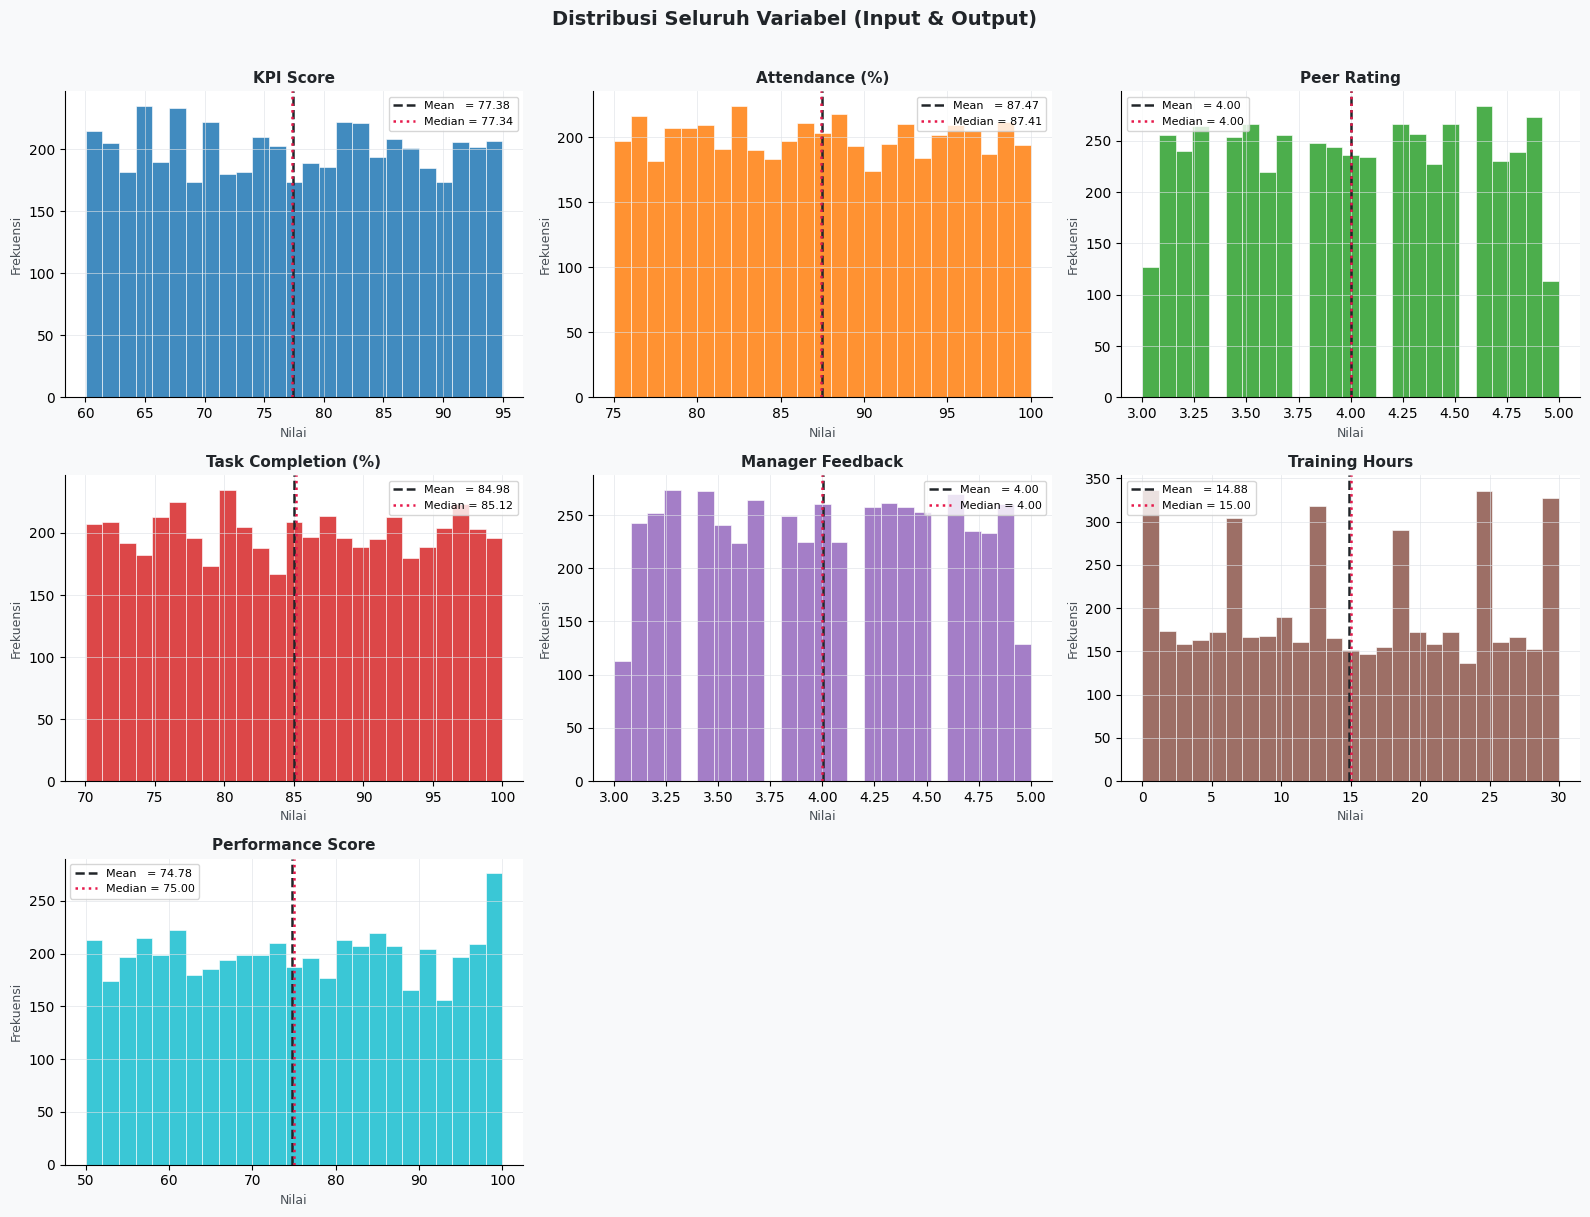

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), facecolor='#F8F9FA')
axes = axes.flatten()
COLORS = ['#1F77B4','#FF7F0E','#2CA02C','#D62728','#9467BD','#8C564B','#17BECF']

for i, (col, clr) in enumerate(zip(SELECTED, COLORS)):
    ax = axes[i]
    ax.set_facecolor('white')
    ax.hist(df[col], bins=25, color=clr, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(df[col].mean(),   color='#212529', lw=1.8, ls='--',
               label=f"Mean   = {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color='#E6194B', lw=1.8, ls=':',
               label=f"Median = {df[col].median():.2f}")
    ax.set_title(col, fontsize=11, fontweight='bold', color='#212529')
    ax.set_xlabel('Nilai', fontsize=9, color='#495057')
    ax.set_ylabel('Frekuensi', fontsize=9, color='#495057')
    ax.legend(fontsize=8)
    ax.grid(True, color='#DEE2E6', linewidth=0.6, alpha=0.7)
    ax.spines[['top','right']].set_visible(False)

# sembunyikan subplot kosong
for j in range(len(SELECTED), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Seluruh Variabel (Input & Output)',
             fontsize=14, fontweight='bold', color='#212529', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Analisis Korelasi

Korelasi Pearson dihitung antara semua variabel. Fokus utamanya adalah korelasi setiap **input terhadap output** (`Performance Score`) untuk memvalidasi pemilihan variabel.

> **Catatan:** Nilai korelasi yang mendekati nol **bukan berarti variabel tidak relevan**. Korelasi Pearson hanya mengukur hubungan **linear**. Nilai mendekati nol justru mengindikasikan bahwa hubungan antar variabel bersifat **non-linear dan kompleks** — ini menjadi justifikasi ilmiah mengapa pendekatan **sistem fuzzy lebih tepat** dibanding model regresi linear.

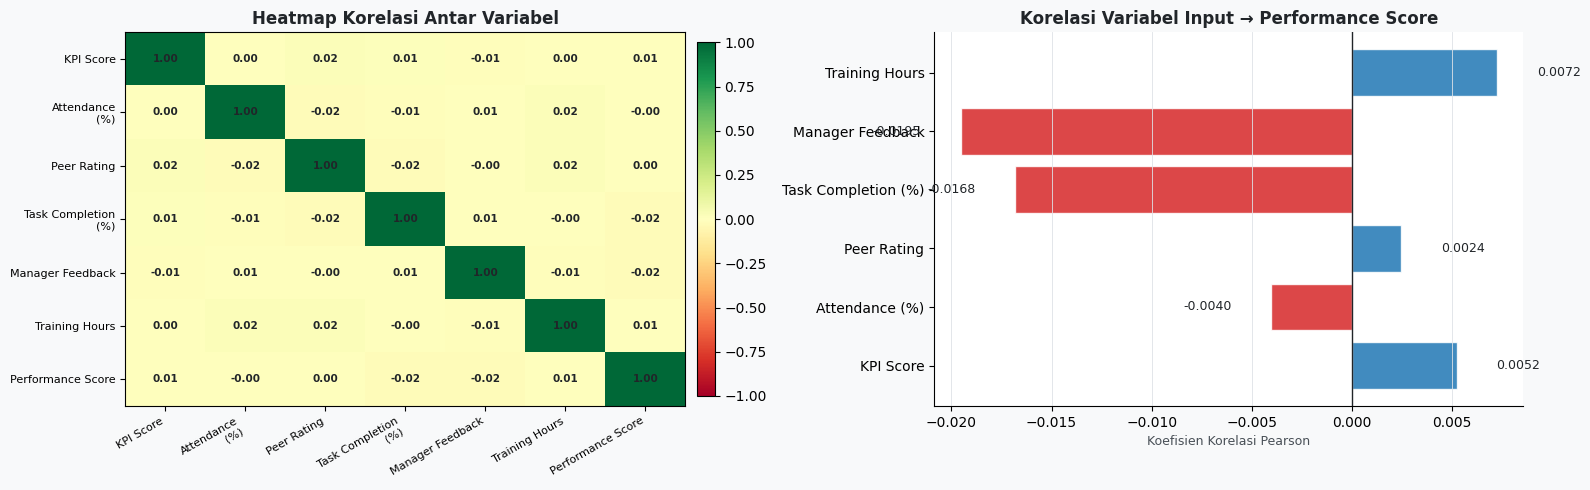


=== Matriks Korelasi (Tabel) ===


,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Manager Feedback,Training Hours,Performance Score
KPI Score,1.0000,0.0025,0.0165,0.0094,-0.0103,0.0026,0.0052
Attendance (%),0.0025,1.0000,-0.0194,-0.0109,0.0053,0.0164,-0.0040
Peer Rating,0.0165,-0.0194,1.0000,-0.0215,-0.0033,0.0170,0.0024
Task Completion (%),0.0094,-0.0109,-0.0215,1.0000,0.0068,-0.0048,-0.0168
Manager Feedback,-0.0103,0.0053,-0.0033,0.0068,1.0000,-0.0107,-0.0195
Training Hours,0.0026,0.0164,0.0170,-0.0048,-0.0107,1.0000,0.0072
Performance Score,0.0052,-0.0040,0.0024,-0.0168,-0.0195,0.0072,1.0000


In [11]:
corr = df[SELECTED].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#F8F9FA')

# --- Heatmap korelasi ---
ax1 = axes[0]
ax1.set_facecolor('white')
im = ax1.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
labels = [c.replace(' (%)', '\n(%)') for c in SELECTED]
ax1.set_xticks(range(len(SELECTED))); ax1.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
ax1.set_yticks(range(len(SELECTED))); ax1.set_yticklabels(labels, fontsize=8)
for i in range(len(SELECTED)):
    for j in range(len(SELECTED)):
        ax1.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                 fontsize=7.5, fontweight='bold', color='#212529')
plt.colorbar(im, ax=ax1, fraction=0.03, pad=0.02)
ax1.set_title('Heatmap Korelasi Antar Variabel', fontsize=12, fontweight='bold', color='#212529')

# --- Bar korelasi input vs output ---
ax2 = axes[1]
ax2.set_facecolor('white')
corr_out    = corr[OUTPUT_COL].drop(OUTPUT_COL)
bar_colors  = ['#1F77B4' if v >= 0 else '#D62728' for v in corr_out.values]
bars = ax2.barh(corr_out.index, corr_out.values, color=bar_colors, edgecolor='white', alpha=0.85)
ax2.axvline(0, color='#212529', lw=1)
for bar, val in zip(bars, corr_out.values):
    offset = 0.002 if val >= 0 else -0.002
    ha     = 'left'  if val >= 0 else 'right'
    ax2.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha=ha, fontsize=9, color='#212529')
ax2.set_title(f'Korelasi Variabel Input → {OUTPUT_COL}', fontsize=12, fontweight='bold', color='#212529')
ax2.set_xlabel('Koefisien Korelasi Pearson', fontsize=9, color='#495057')
ax2.grid(True, axis='x', color='#DEE2E6', linewidth=0.6)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== Matriks Korelasi (Tabel) ===")
corr.round(4)

---
## 8. Penentuan Batas Membership Function

Batas membership function ditentukan menggunakan pendekatan **Percentile-based (Q1, Median, Q3)** yang dikombinasikan dengan nilai ekstrem (Min, Max) dari data aktual. Pendekatan ini dipilih karena:
- Bersumber dari distribusi data nyata, bukan asumsi subjektif
- Setiap himpunan fuzzy mencakup porsi data yang proporsional
- Dapat dipertanggungjawabkan secara ilmiah di laporan

Setiap variabel dibagi menjadi **3 himpunan linguistik** dengan fungsi keanggotaan **triangular** dan **trapezoidal**:
- **Rendah / Buruk / Sedikit** : dari Min hingga sekitar Median, puncak di Q1
- **Sedang / Cukup**           : dari Q1 hingga Q3, puncak di Median
- **Tinggi / Baik / Banyak**  : dari sekitar Median hingga Max, puncak di Q3

In [12]:
# Batas membership function berdasarkan Min, Q1, Median, Q3, Max
# Format per himpunan: [a, b, c] triangular  atau  [a, b, c, d] trapezoidal
# Triangular  : naik dari a ke b (puncak), turun dari b ke c
# Trapezoidal : naik dari a ke b, plateau b–c, turun dari c ke d

MEMBERSHIP = {
    'KPI Score': {
        # Range: [60.01, 94.99]  Q1=68.33  Median=77.34  Q3=86.05
        'Rendah' : [60.00,60.00,64.00,72],   # trapezoidal (ujung kiri flat)
        'Sedang' : [68.33, 77.34, 86.05],           # triangular
        'Tinggi' : [77.34, 86.05, 95.00, 95.00],   # trapezoidal (ujung kanan flat)
    },
    'Attendance (%)': {
        # Range: [75.01, 100.00]  Q1=81.13  Median=87.41  Q3=93.75
        'Rendah' : [75.00, 75.00, 81.13, 87.41],
        'Sedang' : [81.13, 87.41, 93.75],
        'Tinggi' : [87.41, 93.75, 100.00, 100.00],
    },
    'Peer Rating': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Task Completion (%)': {
        # Range: [70.01, 100.00]  Q1=77.32  Median=85.12  Q3=92.47
        'Rendah' : [70.00, 70.00, 77.32, 85.12],
        'Sedang' : [77.32, 85.12, 92.47],
        'Tinggi' : [85.12, 92.47, 100.00, 100.00],
    },
    'Manager Feedback': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Training Hours': {
        # Range: [0, 30]  Q1=7.00  Median=15.00  Q3=23.00
        'Sedikit': [0.00,  0.00,  7.00, 15.00],
        'Cukup'  : [7.00, 15.00, 23.00],
        'Banyak' : [15.00, 23.00, 30.00, 30.00],
    },
    'Performance Score': {
        # Range: [50, 100]  Q1=62.00  Median=75.00  Q3=87.00
        'Rendah' : [50.00, 50.00, 62.00, 75.00],
        'Sedang' : [62.00, 75.00, 87.00],
        'Tinggi' : [75.00, 87.00, 100.00, 100.00],
    },
}

print("=== Ringkasan Batas Membership Function ===")
print(f"{'Variabel':<22} {'Himpunan':<10} {'Tipe':<14} {'Parameter'}")
print("-" * 70)
for var, himpunan in MEMBERSHIP.items():
    for nama, params in himpunan.items():
        tipe = 'Trapezoidal' if len(params) == 4 else 'Triangular'
        print(f"{var:<22} {nama:<10} {tipe:<14} {params}")
    print()

=== Ringkasan Batas Membership Function ===
Variabel               Himpunan   Tipe           Parameter
----------------------------------------------------------------------
KPI Score              Rendah     Trapezoidal    [60.0, 60.0, 64.0, 72]
KPI Score              Sedang     Triangular     [68.33, 77.34, 86.05]
KPI Score              Tinggi     Trapezoidal    [77.34, 86.05, 95.0, 95.0]

Attendance (%)         Rendah     Trapezoidal    [75.0, 75.0, 81.13, 87.41]
Attendance (%)         Sedang     Triangular     [81.13, 87.41, 93.75]
Attendance (%)         Tinggi     Trapezoidal    [87.41, 93.75, 100.0, 100.0]

Peer Rating            Buruk      Trapezoidal    [3.0, 3.0, 3.5, 4.0]
Peer Rating            Cukup      Triangular     [3.5, 4.0, 4.5]
Peer Rating            Baik       Trapezoidal    [4.0, 4.5, 5.0, 5.0]

Task Completion (%)    Rendah     Trapezoidal    [70.0, 70.0, 77.32, 85.12]
Task Completion (%)    Sedang     Triangular     [77.32, 85.12, 92.47]
Task Completion (%)    Ting

### Visualisasi Membership Function

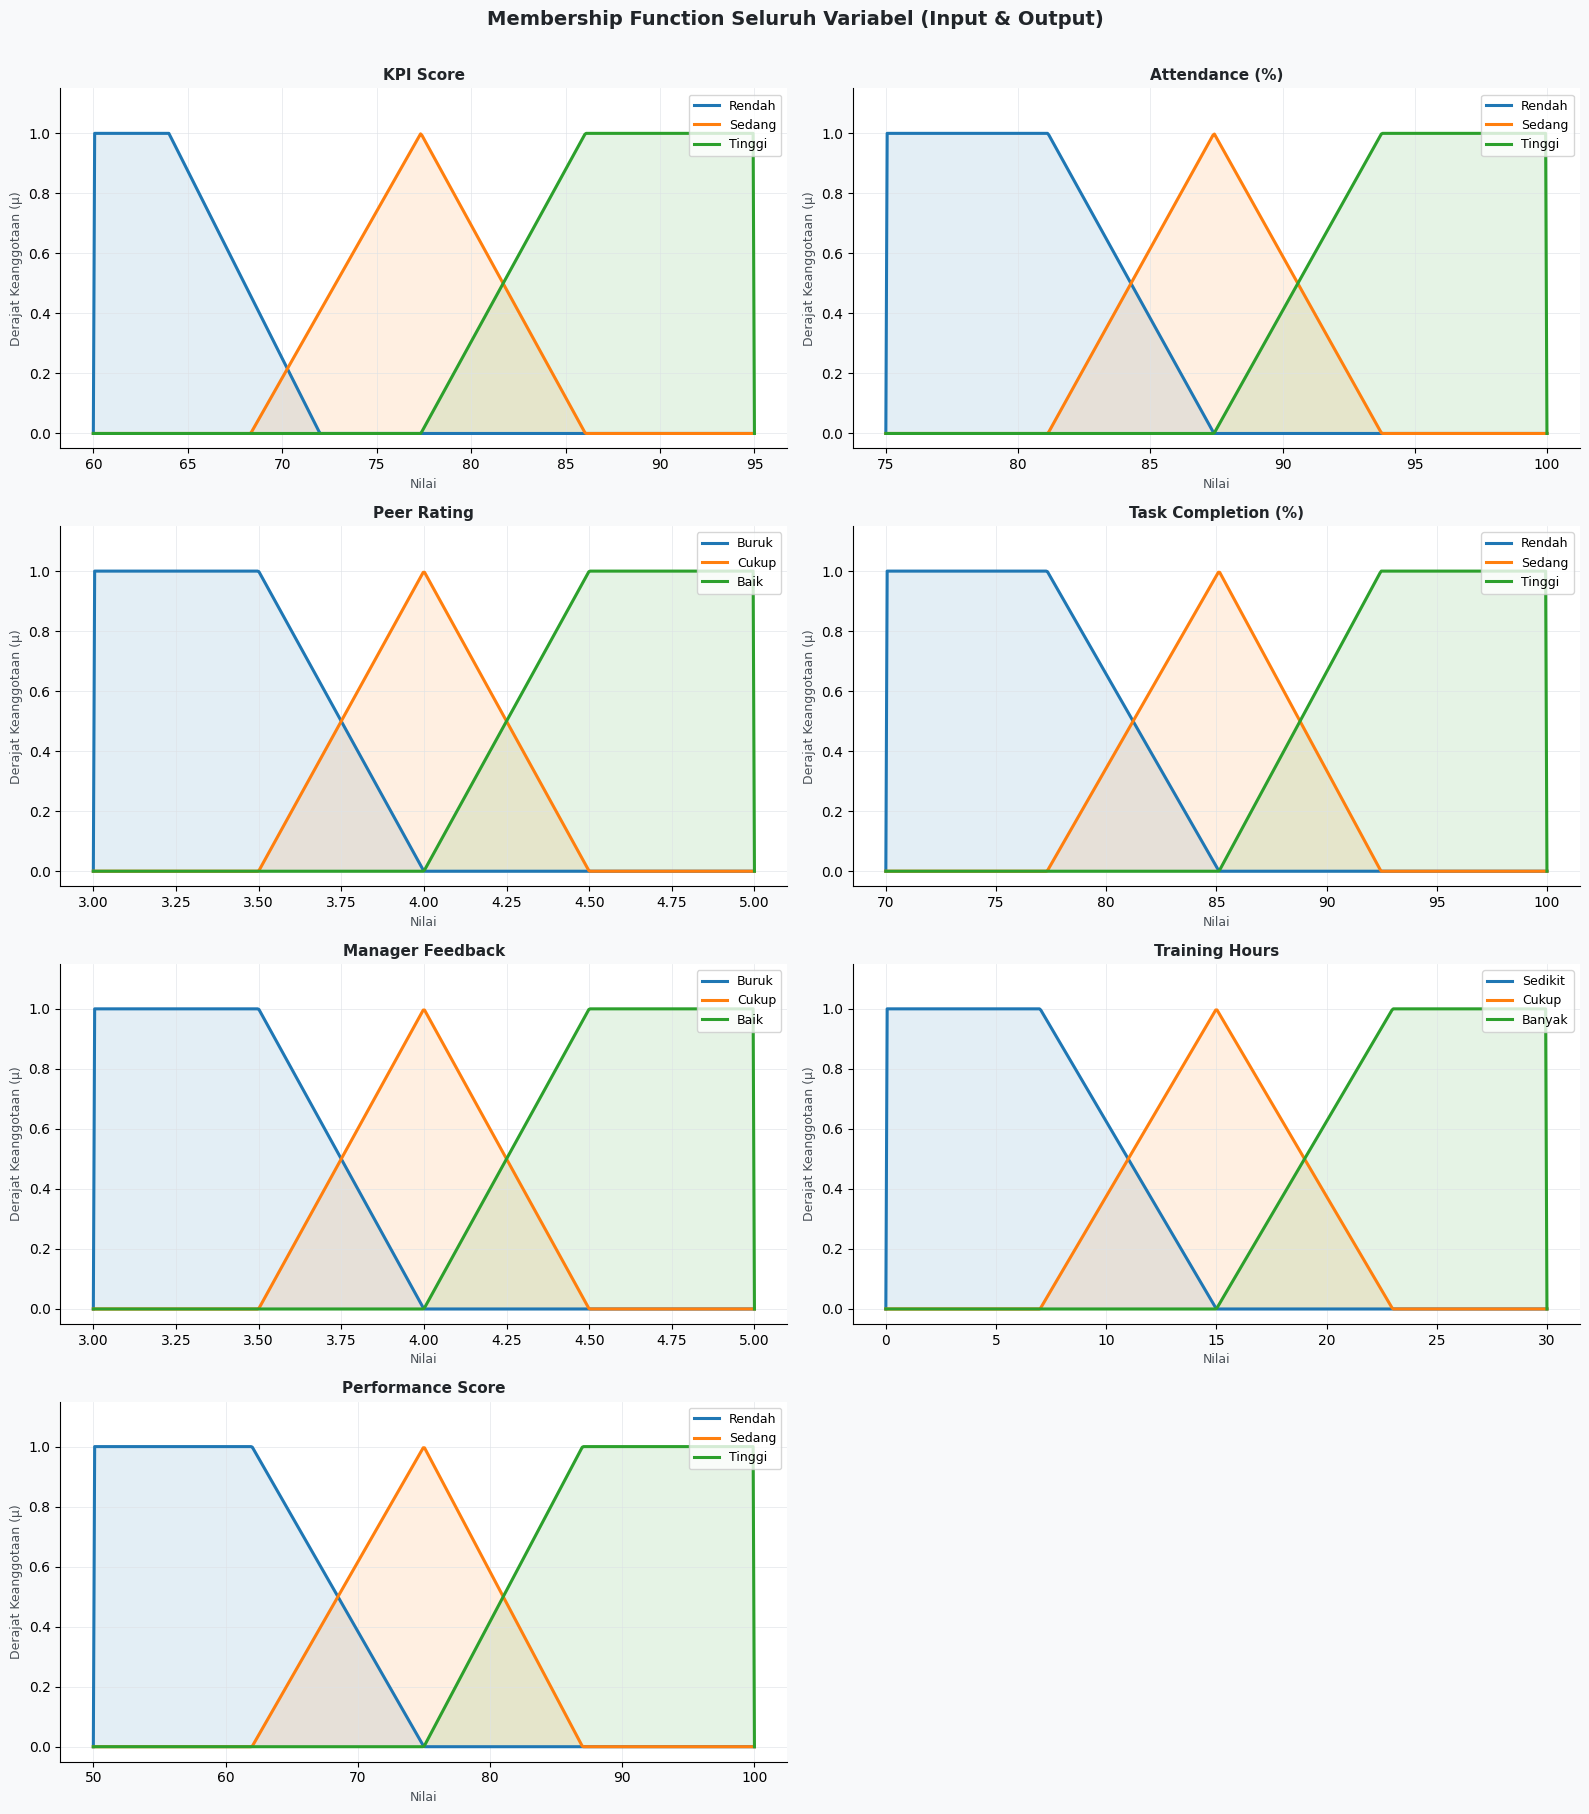

In [13]:
def trimf(x, params):
    """Triangular membership function [a, b, c]"""
    a, b, c = params
    return np.maximum(0, np.minimum((x-a)/(b-a+1e-10), (c-x)/(c-b+1e-10)))

def trapmf(x, params):
    """Trapezoidal membership function [a, b, c, d]"""
    a, b, c, d = params
    return np.maximum(0, np.minimum(
        np.minimum((x-a)/(b-a+1e-10), 1),
        (d-x)/(d-c+1e-10)
    ))

COLORS_MF = ['#1F77B4', '#FF7F0E', '#2CA02C']
fig, axes = plt.subplots(4, 2, figsize=(16, 18), facecolor='#F8F9FA')
axes = axes.flatten()

for idx, (var, himpunan) in enumerate(MEMBERSHIP.items()):
    ax  = axes[idx]
    ax.set_facecolor('white')
    all_params = [p for p in himpunan.values()]
    x_min = min(p[0] for p in all_params)
    x_max = max(p[-1] for p in all_params)
    x = np.linspace(x_min, x_max, 500)

    for (nama, params), clr in zip(himpunan.items(), COLORS_MF):
        if len(params) == 3:
            y = trimf(x, params)
        else:
            y = trapmf(x, params)
        ax.plot(x, y, color=clr, lw=2.2, label=nama)
        ax.fill_between(x, y, alpha=0.12, color=clr)

    ax.set_title(var, fontsize=11, fontweight='bold', color='#212529')
    ax.set_xlabel('Nilai', fontsize=9, color='#495057')
    ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=9, color='#495057')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, color='#DEE2E6', linewidth=0.6, alpha=0.7)
    ax.spines[['top','right']].set_visible(False)

# sembunyikan subplot kosong
for j in range(len(MEMBERSHIP), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Membership Function Seluruh Variabel (Input & Output)',
             fontsize=14, fontweight='bold', color='#212529', y=1.005)
plt.tight_layout()
plt.show()

---
## 9. Ringkasan Preprocessing

Seluruh tahapan preprocessing telah selesai. Berikut ringkasan hasil yang siap digunakan untuk implementasi Fuzzy Mamdani dan Fuzzy Sugeno:

In [11]:
print("======================================================")
print("         RINGKASAN HASIL PREPROCESSING                ")
print("======================================================")
print(f"  Total data bersih       : {len(df):,} baris")
print(f"  Variabel input          : {len(INPUT_COLS)} kolom")
print(f"  Variabel output         : {OUTPUT_COL}")
print(f"  Missing values          : 0 (tidak ada)")
print(f"  Outlier                 : 0 (tidak ada)")
print(f"  Metode MF               : Triangular & Trapezoidal")
print(f"  Jumlah himpunan per var : 3 (Rendah/Buruk/Sedikit,")
print(f"                            Sedang/Cukup, Tinggi/Baik/Banyak)")
print("------------------------------------------------------")
print("  Variabel & Universe of Discourse:")
for col in SELECTED:
    tag = "[OUTPUT]" if col == OUTPUT_COL else "[INPUT] "
    print(f"  {tag}  {col:<22}: [{df[col].min():.2f}, {df[col].max():.2f}]")
print("======================================================")
print("  Dataset siap digunakan untuk implementasi:")
print("    - Fuzzy Mamdani")
print("    - Fuzzy Sugeno")
print("  Gunakan dictionary MEMBERSHIP untuk batas MF.")
print("======================================================")

         RINGKASAN HASIL PREPROCESSING                
  Total data bersih       : 5,000 baris
  Variabel input          : 6 kolom
  Variabel output         : Performance Score
  Missing values          : 0 (tidak ada)
  Outlier                 : 0 (tidak ada)
  Metode MF               : Triangular & Trapezoidal
  Jumlah himpunan per var : 3 (Rendah/Buruk/Sedikit,
                            Sedang/Cukup, Tinggi/Baik/Banyak)
------------------------------------------------------
  Variabel & Universe of Discourse:
  [INPUT]   KPI Score             : [60.01, 94.99]
  [INPUT]   Attendance (%)        : [75.01, 100.00]
  [INPUT]   Peer Rating           : [3.00, 5.00]
  [INPUT]   Task Completion (%)   : [70.01, 100.00]
  [INPUT]   Manager Feedback      : [3.00, 5.00]
  [INPUT]   Training Hours        : [0.00, 30.00]
  [OUTPUT]  Performance Score     : [50.00, 100.00]
  Dataset siap digunakan untuk implementasi:
    - Fuzzy Mamdani
    - Fuzzy Sugeno
  Gunakan dictionary MEMBERSHIP untuk bat

In [14]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(df[INPUT_COLS], df[OUTPUT_COL])

importance = pd.Series(rf.feature_importances_, index=INPUT_COLS)
print(importance.sort_values(ascending=False))

Task Completion (%)    0.214203
Attendance (%)         0.211537
KPI Score              0.204650
Training Hours         0.133251
Peer Rating            0.119816
Manager Feedback       0.116543
dtype: float64
